# OpenNTN PHY notebook

This notebook uses the modular files in `src/` and runs an SNR sweep with optional Monte Carlo averaging.

In [1]:
import sys
import os

sys.path.append(os.path.abspath('.'))

%load_ext autoreload
%autoreload 2

In [26]:
import numpy as np

from src import (
    ActionConfig,
    SimulationConfig,
    OpenNTNPhyExecutor,
    run_snr_sweep,
    run_snr_sweep_mc,
    plot_results,
)

In [27]:
action_cfg = ActionConfig(
    modulation='16QAM',
    code_rate=0.25,
    power_boost_db=0.0,
)

sim_cfg = SimulationConfig(
    scenario='urb',
    channel_model_name='Urban',
    perfect_csi=True,
    doppler_enabled=True,
    elevation_angle=50.0,
    carrier_frequency=2.0e9,
    batch_size=512,
    num_ut=1,
    num_ut_ant=1,
    num_bs_ant=1,
    num_ofdm_symbols=14,
    fft_size=256,
    subcarrier_spacing=15e3,
    cyclic_prefix_length=16,
    pilot_ofdm_symbol_indices=[2, 11],
)

action_cfg, sim_cfg

(ActionConfig(modulation='16QAM', code_rate=0.25, power_boost_db=0.0),
 SimulationConfig(scenario='urb', channel_model_name='Urban', perfect_csi=True, doppler_enabled=True, elevation_angle=50.0, carrier_frequency=2000000000.0, batch_size=512, num_ut=1, num_ut_ant=1, num_bs_ant=1, num_ofdm_symbols=14, fft_size=256, subcarrier_spacing=15000.0, cyclic_prefix_length=16, pilot_ofdm_symbol_indices=[2, 11]))

In [28]:
executor = OpenNTNPhyExecutor(action_cfg=action_cfg, sim_cfg=sim_cfg)
executor

In [29]:
snr_db_list = np.arange(-5, 21, 0.5)
snr_db_list[:10], snr_db_list[-1]

(array([-5. , -4.5, -4. , -3.5, -3. , -2.5, -2. , -1.5, -1. , -0.5]), 20.5)

## Single sweep
Use this for quick debugging.

In [30]:
results_single = run_snr_sweep(executor, snr_db_list, verbose=True)

SNR= -5.0 dB | BER=4.0340e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.5 dB | BER=3.9623e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.0 dB | BER=3.8814e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.5 dB | BER=3.7960e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.0 dB | BER=3.7050e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.5 dB | BER=3.6041e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.0 dB | BER=3.4909e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.5 dB | BER=3.3732e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.0 dB | BER=3.2331e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -0.5 dB | BER=3.0773e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.0 dB | BER=2.8956e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.5 dB | BER=2.7038e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.0 dB | BER=2.4383e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.5 dB | BER=2.0647e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  2.0 dB | BER=1.3009e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  2.5 dB | BER=2.1519e-02 | BLER=7.5195e-01 | iSE=0.2480
SNR=  3.0 dB | BER=1.900

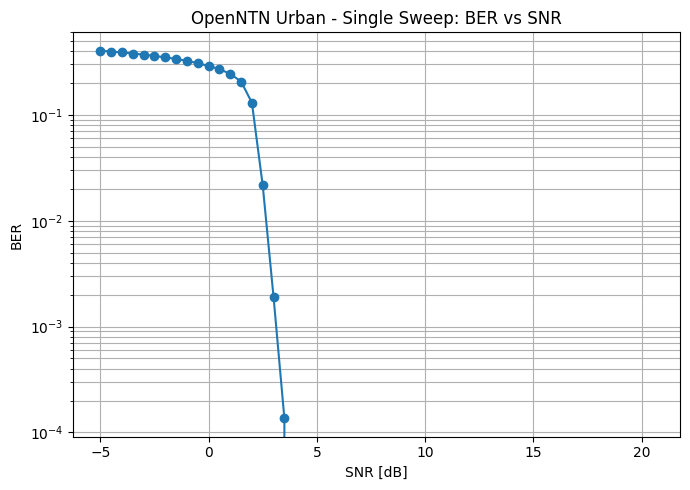

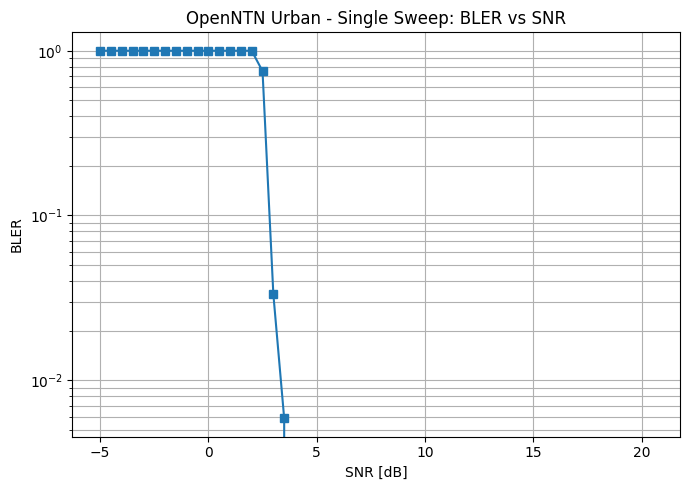

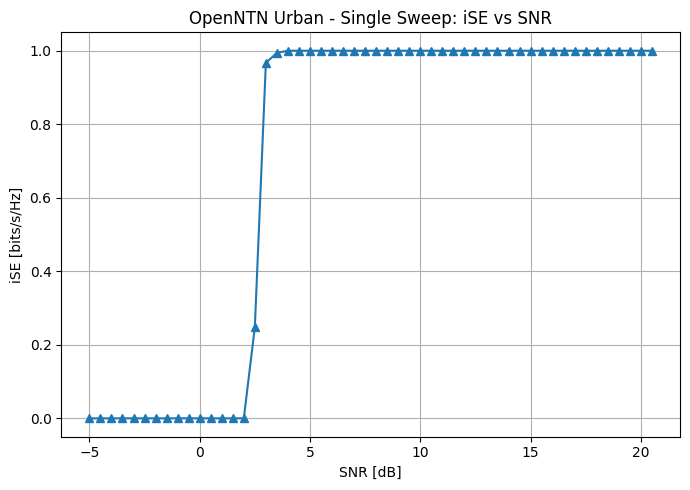

In [32]:
plot_results(results_single, title_prefix='OpenNTN Urban - Single Sweep')

## Monte Carlo averaged sweep
Use this for smoother BER/BLER curves.

In [33]:
results_mc = run_snr_sweep_mc(executor, snr_db_list, num_iter=10, verbose=True)

Iteration 1/10
SNR= -5.0 dB | BER=4.0273e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.5 dB | BER=3.9632e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -4.0 dB | BER=3.8762e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.5 dB | BER=3.7971e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -3.0 dB | BER=3.7001e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.5 dB | BER=3.6000e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -2.0 dB | BER=3.4923e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.5 dB | BER=3.3649e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -1.0 dB | BER=3.2239e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR= -0.5 dB | BER=3.0882e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.0 dB | BER=2.9130e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  0.5 dB | BER=2.7006e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.0 dB | BER=2.4409e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  1.5 dB | BER=2.0542e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  2.0 dB | BER=1.3019e-01 | BLER=1.0000e+00 | iSE=0.0000
SNR=  2.5 dB | BER=2.1451e-02 | BLER=7.9102e-01 | iSE=0.2090
SNR=  3.0

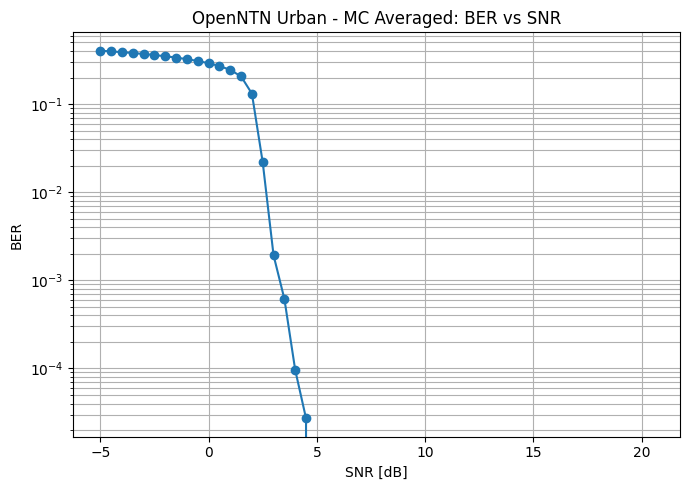

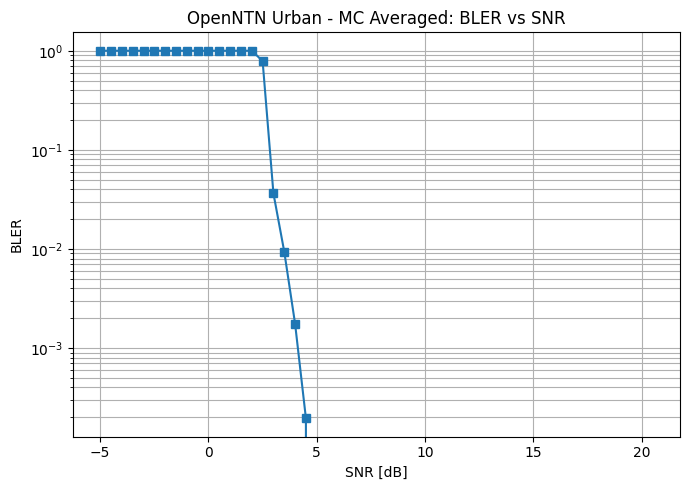

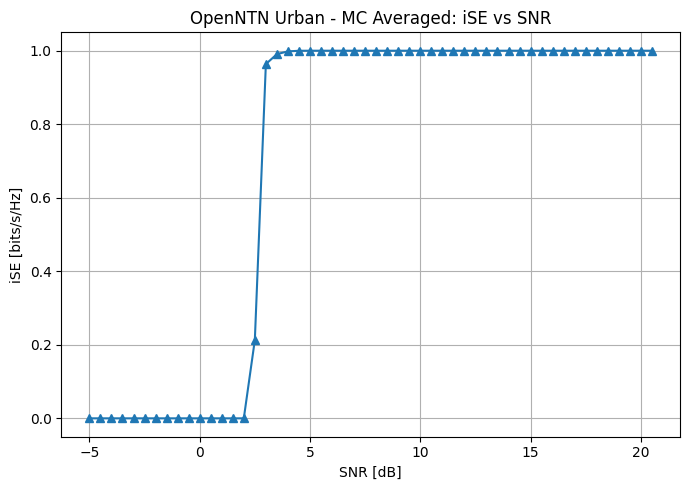

In [34]:
plot_results(results_mc, title_prefix='OpenNTN Urban - MC Averaged')

In [35]:
# Optional: save results
np.savez('results_openntn_urban.npz', **results_mc)